# SME Credit Card Retention Campaign: A/B Testing and Predictive Analytics

## Business Context

A leading financial institution manages a large portfolio of SME (Small and Medium Enterprise)
credit card customers. In a competitive credit card market, acquiring a new customer costs
significantly more than retaining an existing one — industry estimates peg acquisition cost
at 5 to 7 times that of retention. When an SME customer cancels their card, the bank loses
not only the annual fee revenue but also the interchange fee income from every future transaction,
cross-sell opportunities, and the customer's lifetime value.

To combat this, the marketing team designed a retention campaign targeting SME and other
customer segments. The campaign split customers into multiple offer types:

- Cashback
- Travel Rewards
- Low Interest
- Premium Lifestyle
- Dining Rewards
- Balance Transfer (effectively the control proxy)

Some customers received high-engagement incentives like Cashback or Travel Rewards, while
others received more transactional or neutral offers. The campaign was delivered across
channels including Email, SMS, Branch, Phone Call, and Social Media.

## Business Objectives

1. Determine whether the retention offers statistically significantly improved 6-month retention
2. Identify which offer type drove the most meaningful uplift
3. Build a predictive model that scores each customer's probability of accepting a future offer
4. Generate a recommendation engine that guides the Sales team on the next best action

## Business KPIs

- Retention Rate: Percentage of customers still active after 6 months
- Offer Acceptance Rate: Percentage of customers who accepted the campaign offer
- Campaign ROI: Revenue preserved versus campaign cost
- Churn Reduction: Percentage point improvement in retention over baseline

## Why A/B Testing Here

A/B testing (or more precisely, a multi-arm treatment test in this case) allows us to
isolate the causal effect of the offer from natural attrition behavior. Without it,
we could not determine whether customers who stayed would have stayed anyway, regardless
of the offer. By comparing treatment groups statistically, we separate signal from noise
and give the business defensible, evidence-based conclusions.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Statistical testing
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, norm

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Model persistence
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# Aesthetic configuration — keeping it clean and professional
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_palette("muted")

# Load the dataset
DATA_PATH = "credit_card_marketing_campaign_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Column names:")
for col in df.columns:
    print(f"  {col}")

Dataset loaded successfully.
Shape: 100,000 rows x 16 columns

Column names:
  Account_ID
  Customer_Age
  Annual_Income_USD
  Credit_Score
  Offer_Type
  Discount_Percent
  Credit_Limit_USD
  Avg_Monthly_Spend_USD
  Campaign_Cost_USD
  Profit_Margin_Percent
  Campaign_Channel
  Region
  Customer_Segment
  Accepted_Offer
  Retained_6_Months
  Campaign_Date


## Understanding the Dataset

Before we touch any model or test, we need to develop a thorough understanding of each column.
This is not just a technical exercise — each field carries a business story.

| Column | Type | Business Meaning |
|---|---|---|
| Account_ID | Categorical | Unique customer identifier |
| Customer_Age | Numeric | Age of the customer in years |
| Annual_Income_USD | Numeric | Customer's declared or derived annual income |
| Credit_Score | Numeric | Credit bureau score; proxy for financial health |
| Offer_Type | Categorical | The treatment arm — type of retention offer given |
| Discount_Percent | Numeric | Discount or reward percentage attached to the offer |
| Credit_Limit_USD | Numeric | Approved credit limit — proxy for credit tier |
| Avg_Monthly_Spend_USD | Numeric | Average monthly card spend in USD |
| Campaign_Cost_USD | Numeric | Cost to the bank of delivering this customer's campaign |
| Profit_Margin_Percent | Numeric | Net margin from this customer |
| Campaign_Channel | Categorical | How the offer was delivered |
| Region | Categorical | Geographic region of the customer |
| Customer_Segment | Categorical | SME, HNI, Mass Market, Student, Affluent |
| Accepted_Offer | Binary (0/1) | Whether the customer accepted the offer |
| Retained_6_Months | Binary (0/1) | Whether the customer remained active after 6 months |
| Campaign_Date | Date | Date the campaign was executed |

Key observations even before analysis:
- Accepted_Offer and Retained_6_Months are our primary outcome variables
- Offer_Type is our treatment variable — the A/B grouping
- The dataset has no missing values, which is unusually clean and suggests it may be
  pre-processed or synthetically generated with production-like distributions

In [5]:
class DataInspector:
    """
    A reusable utility class for profiling any pandas DataFrame.
    Clean OOP pattern — easy to extend and reuse across projects.
    """

    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe

    def shape_summary(self):
        print(f"Rows   : {self.df.shape[0]:,}")
        print(f"Columns: {self.df.shape[1]}")

    def dtype_summary(self):
        print("\nData Types:")
        print(self.df.dtypes.to_string())

    def missing_summary(self):
        missing = self.df.isnull().sum()
        pct = (missing / len(self.df) * 100).round(2)
        report = pd.DataFrame({"Missing Count": missing, "Missing %": pct})
        report = report[report["Missing Count"] > 0]
        if report.empty:
            print("\nNo missing values detected. The dataset is complete.")
        else:
            print("\nMissing Value Report:")
            print(report.to_string())

    def duplicate_summary(self):
        dupes = self.df.duplicated().sum()
        print(f"\nDuplicate Rows: {dupes:,}")

    def cardinality_summary(self):
        print("\nUnique Value Counts per Column:")
        for col in self.df.columns:
            n = self.df[col].nunique()
            print(f"  {col:<30}: {n:>6,} unique values")

    def categorical_distributions(self, cols):
        print("\nCategorical Value Distributions:")
        for col in cols:
            print(f"\n  {col}:")
            vc = self.df[col].value_counts()
            for val, count in vc.items():
                pct = count / len(self.df) * 100
                print(f"    {str(val):<30} {count:>8,}  ({pct:.1f}%)")

    def run_full_profile(self):
        self.shape_summary()
        self.dtype_summary()
        self.missing_summary()
        self.duplicate_summary()
        self.cardinality_summary()
        cat_cols = self.df.select_dtypes(include="object").columns.tolist()
        self.categorical_distributions(cat_cols)


# Run the full profile
inspector = DataInspector(df)
inspector.run_full_profile()

print("\n\nNumerical Statistical Summary:")
print(df.describe().T.to_string())

Rows   : 100,000
Columns: 16

Data Types:
Account_ID                   str
Customer_Age               int64
Annual_Income_USD        float64
Credit_Score               int64
Offer_Type                   str
Discount_Percent         float64
Credit_Limit_USD         float64
Avg_Monthly_Spend_USD    float64
Campaign_Cost_USD        float64
Profit_Margin_Percent    float64
Campaign_Channel             str
Region                       str
Customer_Segment             str
Accepted_Offer             int64
Retained_6_Months          int64
Campaign_Date                str

No missing values detected. The dataset is complete.

Duplicate Rows: 0

Unique Value Counts per Column:
  Account_ID                    : 100,000 unique values
  Customer_Age                  :     49 unique values
  Annual_Income_USD             : 97,237 unique values
  Credit_Score                  :    382 unique values
  Offer_Type                    :      6 unique values
  Discount_Percent              :  3,001 unique 

## Data Cleaning

A clean dataset does not mean analysis-ready. We still need to:

1. Confirm no duplicates on Account_ID (our natural key)
2. Parse Campaign_Date into a proper datetime object and extract temporal features
3. Verify that binary columns (Accepted_Offer, Retained_6_Months) contain only 0 and 1
4. Validate numerical columns for implausible values (negative spend, impossible credit scores)
5. Examine outliers — not to blindly remove them, but to understand whether they represent
   genuine high-value customers or data anomalies

Our outlier philosophy: In a credit card portfolio, high-income, high-spend customers are
real and valuable. We will not winsorize or remove extreme values unless they are clearly
erroneous (e.g., negative income). We will note them for the modeling phase where scaling
will manage their influence.

In [6]:
class DataCleaner:
    """
    Encapsulates all cleaning logic. Operates on a copy of the dataframe
    to keep the raw data intact for reference.
    """

    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.copy()
        self.cleaning_log = []

    def check_account_id_uniqueness(self):
        n_dupes = self.df["Account_ID"].duplicated().sum()
        if n_dupes == 0:
            self.cleaning_log.append("Account_ID: All 100,000 IDs are unique. No key collision.")
        else:
            self.cleaning_log.append(f"Account_ID: {n_dupes} duplicate IDs found. Investigate.")

    def parse_dates(self):
        self.df["Campaign_Date"] = pd.to_datetime(self.df["Campaign_Date"])
        self.df["Campaign_Month"] = self.df["Campaign_Date"].dt.month
        self.df["Campaign_Year"] = self.df["Campaign_Date"].dt.year
        self.df["Campaign_Quarter"] = self.df["Campaign_Date"].dt.quarter
        self.cleaning_log.append("Campaign_Date: Parsed to datetime. Extracted Month, Year, Quarter.")

    def validate_binary_columns(self):
        for col in ["Accepted_Offer", "Retained_6_Months"]:
            unique_vals = set(self.df[col].unique())
            if unique_vals == {0, 1}:
                self.cleaning_log.append(f"{col}: Valid binary (0/1 only).")
            else:
                self.cleaning_log.append(f"{col}: Unexpected values found: {unique_vals}")

    def validate_numeric_ranges(self):
        checks = {
            "Customer_Age": (18, 100),
            "Annual_Income_USD": (0, 10_000_000),
            "Credit_Score": (300, 900),
            "Avg_Monthly_Spend_USD": (0, 1_000_000),
            "Discount_Percent": (0, 100),
        }
        for col, (lo, hi) in checks.items():
            out = self.df[(self.df[col] < lo) | (self.df[col] > hi)]
            if len(out) == 0:
                self.cleaning_log.append(f"{col}: All values within [{lo}, {hi}]. Clean.")
            else:
                self.cleaning_log.append(
                    f"{col}: {len(out)} values outside [{lo}, {hi}]. Review needed."
                )

    def check_outliers_iqr(self, cols):
        print("\nOutlier Detection (IQR method, 1.5x fence):")
        for col in cols:
            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)
            iqr = q3 - q1
            fence_lo = q1 - 1.5 * iqr
            fence_hi = q3 + 1.5 * iqr
            n_outliers = ((self.df[col] < fence_lo) | (self.df[col] > fence_hi)).sum()
            pct = n_outliers / len(self.df) * 100
            print(f"  {col:<30}: {n_outliers:>5,} outliers ({pct:.1f}%)  "
                  f"[fence: {fence_lo:.0f} to {fence_hi:.0f}]")

    def print_log(self):
        print("\nCleaning Log:")
        for entry in self.cleaning_log:
            print(f"  - {entry}")

    def get_clean_df(self):
        return self.df


cleaner = DataCleaner(df)
cleaner.check_account_id_uniqueness()
cleaner.parse_dates()
cleaner.validate_binary_columns()
cleaner.validate_numeric_ranges()
cleaner.check_outliers_iqr([
    "Annual_Income_USD", "Credit_Limit_USD",
    "Avg_Monthly_Spend_USD", "Campaign_Cost_USD", "Profit_Margin_Percent"
])
cleaner.print_log()

df_clean = cleaner.get_clean_df()
print(f"\nClean dataset shape: {df_clean.shape}")


Outlier Detection (IQR method, 1.5x fence):
  Annual_Income_USD             :   349 outliers (0.3%)  [fence: -6422 to 155946]
  Credit_Limit_USD              :     0 outliers (0.0%)  [fence: -23626 to 74580]
  Avg_Monthly_Spend_USD         :     0 outliers (0.0%)  [fence: -3329 to 10429]
  Campaign_Cost_USD             :     0 outliers (0.0%)  [fence: -60 to 220]
  Profit_Margin_Percent         :     0 outliers (0.0%)  [fence: -13 to 58]

Cleaning Log:
  - Account_ID: All 100,000 IDs are unique. No key collision.
  - Campaign_Date: Parsed to datetime. Extracted Month, Year, Quarter.
  - Accepted_Offer: Valid binary (0/1 only).
  - Retained_6_Months: Valid binary (0/1 only).
  - Customer_Age: All values within [18, 100]. Clean.
  - Annual_Income_USD: All values within [0, 10000000]. Clean.
  - Credit_Score: All values within [300, 900]. Clean.
  - Avg_Monthly_Spend_USD: All values within [0, 1000000]. Clean.
  - Discount_Percent: All values within [0, 100]. Clean.

Clean dataset shape:

## Exploratory Data Analysis

EDA is where the data starts talking to us. Our goal here is not just to produce charts —
it is to build a mental model of how this customer population behaves, which offer types
perform, and what business patterns emerge. Every chart below is driven by a specific question.

Questions we want to answer:
- What is the overall retention rate across the portfolio?
- Which offer type drives the highest acceptance and retention?
- How does spend behavior differ across segments?
- Is there a relationship between credit score and retention?
- Are there channel-driven differences in acceptance rates?
- How correlated are the numerical features?

## EDA — Retention and Acceptance Overview

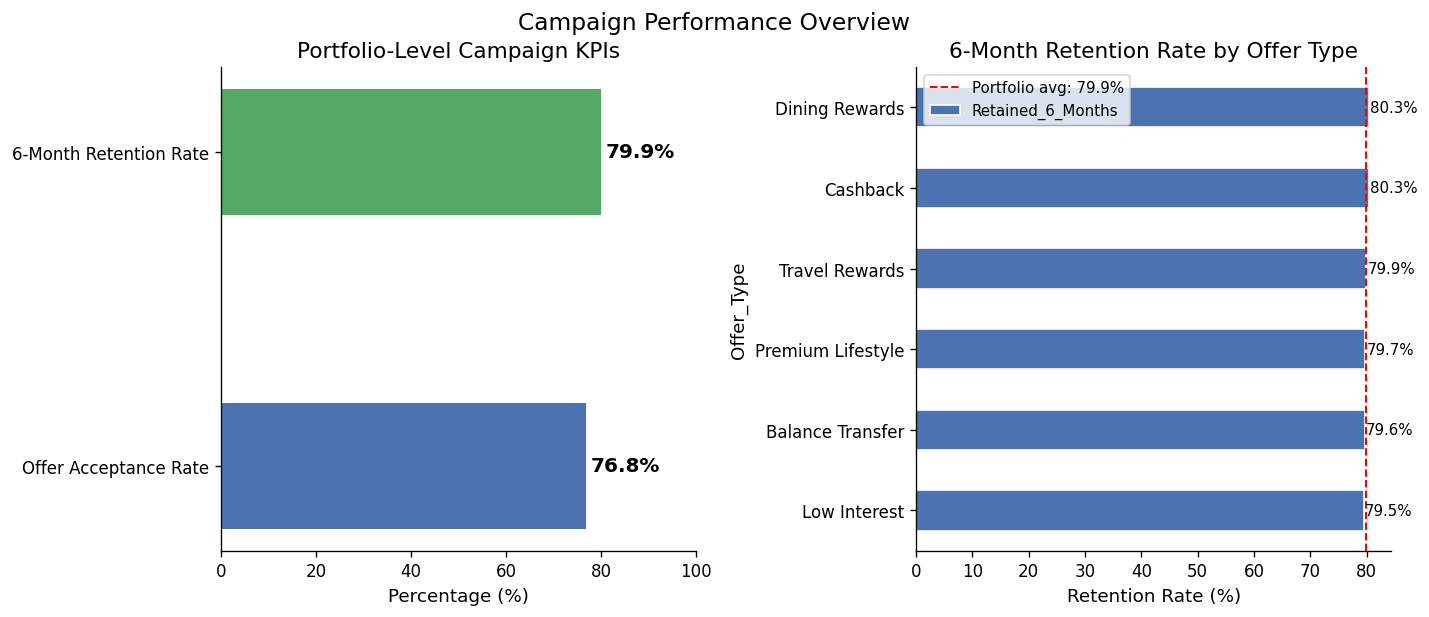


Portfolio Offer Acceptance Rate : 76.8%
Portfolio 6-Month Retention Rate: 79.9%

Retention Rate by Offer Type:
Offer_Type
Low Interest         79.498058
Balance Transfer     79.631537
Premium Lifestyle    79.714303
Travel Rewards       79.930858
Cashback             80.328461
Dining Rewards       80.340287


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Offer acceptance rate
accept_rate = df_clean["Accepted_Offer"].mean() * 100
retain_rate = df_clean["Retained_6_Months"].mean() * 100

kpi_labels = ["Offer Acceptance Rate", "6-Month Retention Rate"]
kpi_values = [accept_rate, retain_rate]
colors = ["#4C72B0", "#55A868"]

bars = axes[0].barh(kpi_labels, kpi_values, color=colors, height=0.4)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Percentage (%)")
axes[0].set_title("Portfolio-Level Campaign KPIs")
for bar, val in zip(bars, kpi_values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=12, fontweight="bold")

# Offer Type: Retention rates
offer_retention = (
    df_clean.groupby("Offer_Type")["Retained_6_Months"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)
offer_retention.plot(kind="barh", ax=axes[1], color="#4C72B0", edgecolor="white")
axes[1].set_xlabel("Retention Rate (%)")
axes[1].set_title("6-Month Retention Rate by Offer Type")
axes[1].axvline(retain_rate, color="red", linestyle="--", linewidth=1.2, label=f"Portfolio avg: {retain_rate:.1f}%")
axes[1].legend(fontsize=9)
for i, (val, label) in enumerate(zip(offer_retention.values, offer_retention.index)):
    axes[1].text(val + 0.2, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.suptitle("Campaign Performance Overview", fontsize=14, y=1.02)
plt.savefig("kpi_overview.png", bbox_inches="tight")
plt.show()

print(f"\nPortfolio Offer Acceptance Rate : {accept_rate:.1f}%")
print(f"Portfolio 6-Month Retention Rate: {retain_rate:.1f}%")
print(f"\nRetention Rate by Offer Type:")
print(offer_retention.to_string())

##  EDA — Customer Segment Analysis

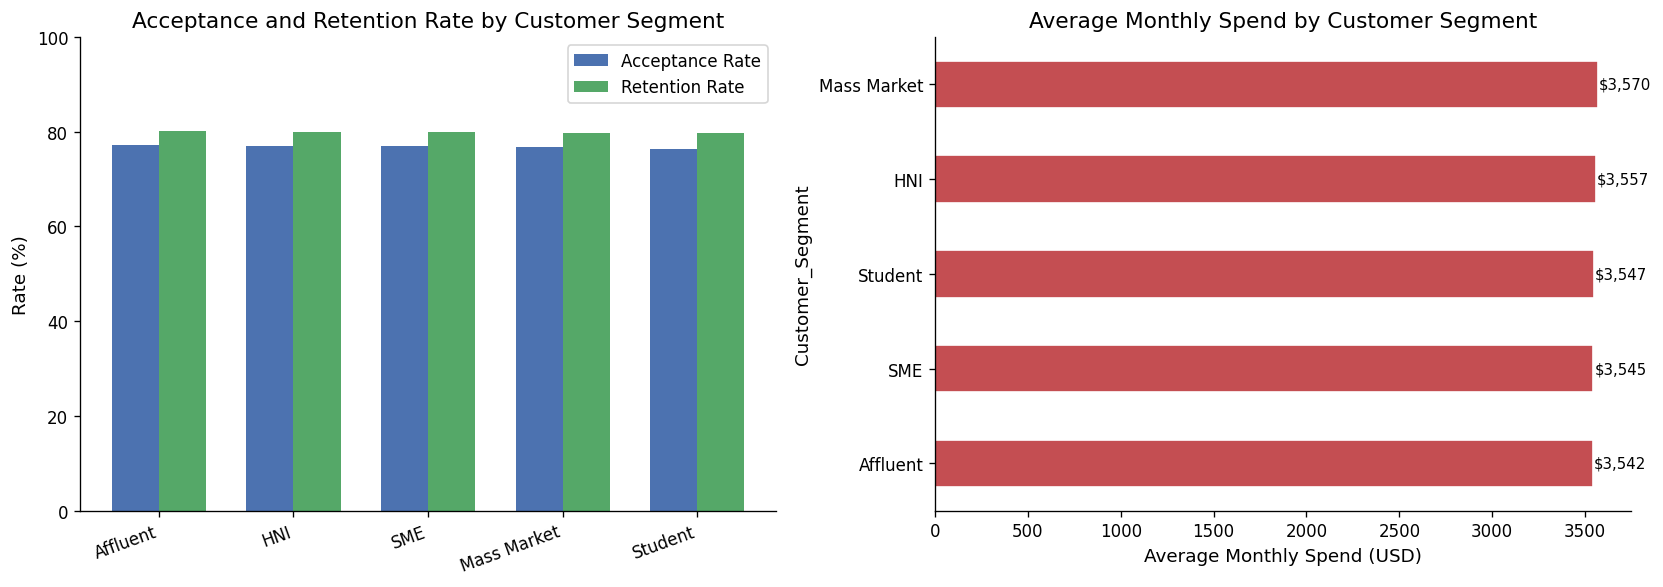

Acceptance Rate by Segment:
Customer_Segment
Affluent       77.262239
HNI            76.931122
SME            76.916554
Mass Market    76.675845
Student        76.273734

Retention Rate by Segment:
Customer_Segment
Affluent       80.211677
HNI            79.884456
Mass Market    79.844806
SME            79.814455
Student        79.780572


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acceptance rate by segment
seg_accept = (
    df_clean.groupby("Customer_Segment")["Accepted_Offer"]
    .mean().mul(100).sort_values(ascending=False)
)
seg_retain = (
    df_clean.groupby("Customer_Segment")["Retained_6_Months"]
    .mean().mul(100).sort_values(ascending=False)
)

x = np.arange(len(seg_accept))
width = 0.35

axes[0].bar(x - width/2, seg_accept.values, width, label="Acceptance Rate", color="#4C72B0")
axes[0].bar(x + width/2, seg_retain.values, width, label="Retention Rate", color="#55A868")
axes[0].set_xticks(x)
axes[0].set_xticklabels(seg_accept.index, rotation=20, ha="right")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Acceptance and Retention Rate by Customer Segment")
axes[0].legend()
axes[0].set_ylim(0, 100)

# Avg monthly spend by segment
seg_spend = (
    df_clean.groupby("Customer_Segment")["Avg_Monthly_Spend_USD"]
    .mean().sort_values(ascending=True)
)
seg_spend.plot(kind="barh", ax=axes[1], color="#C44E52", edgecolor="white")
axes[1].set_xlabel("Average Monthly Spend (USD)")
axes[1].set_title("Average Monthly Spend by Customer Segment")
for i, val in enumerate(seg_spend.values):
    axes[1].text(val + 5, i, f"${val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("segment_analysis.png", bbox_inches="tight")
plt.show()

print("Acceptance Rate by Segment:")
print(seg_accept.to_string())
print("\nRetention Rate by Segment:")
print(seg_retain.to_string())

## EDA — Customer Segment Analysis

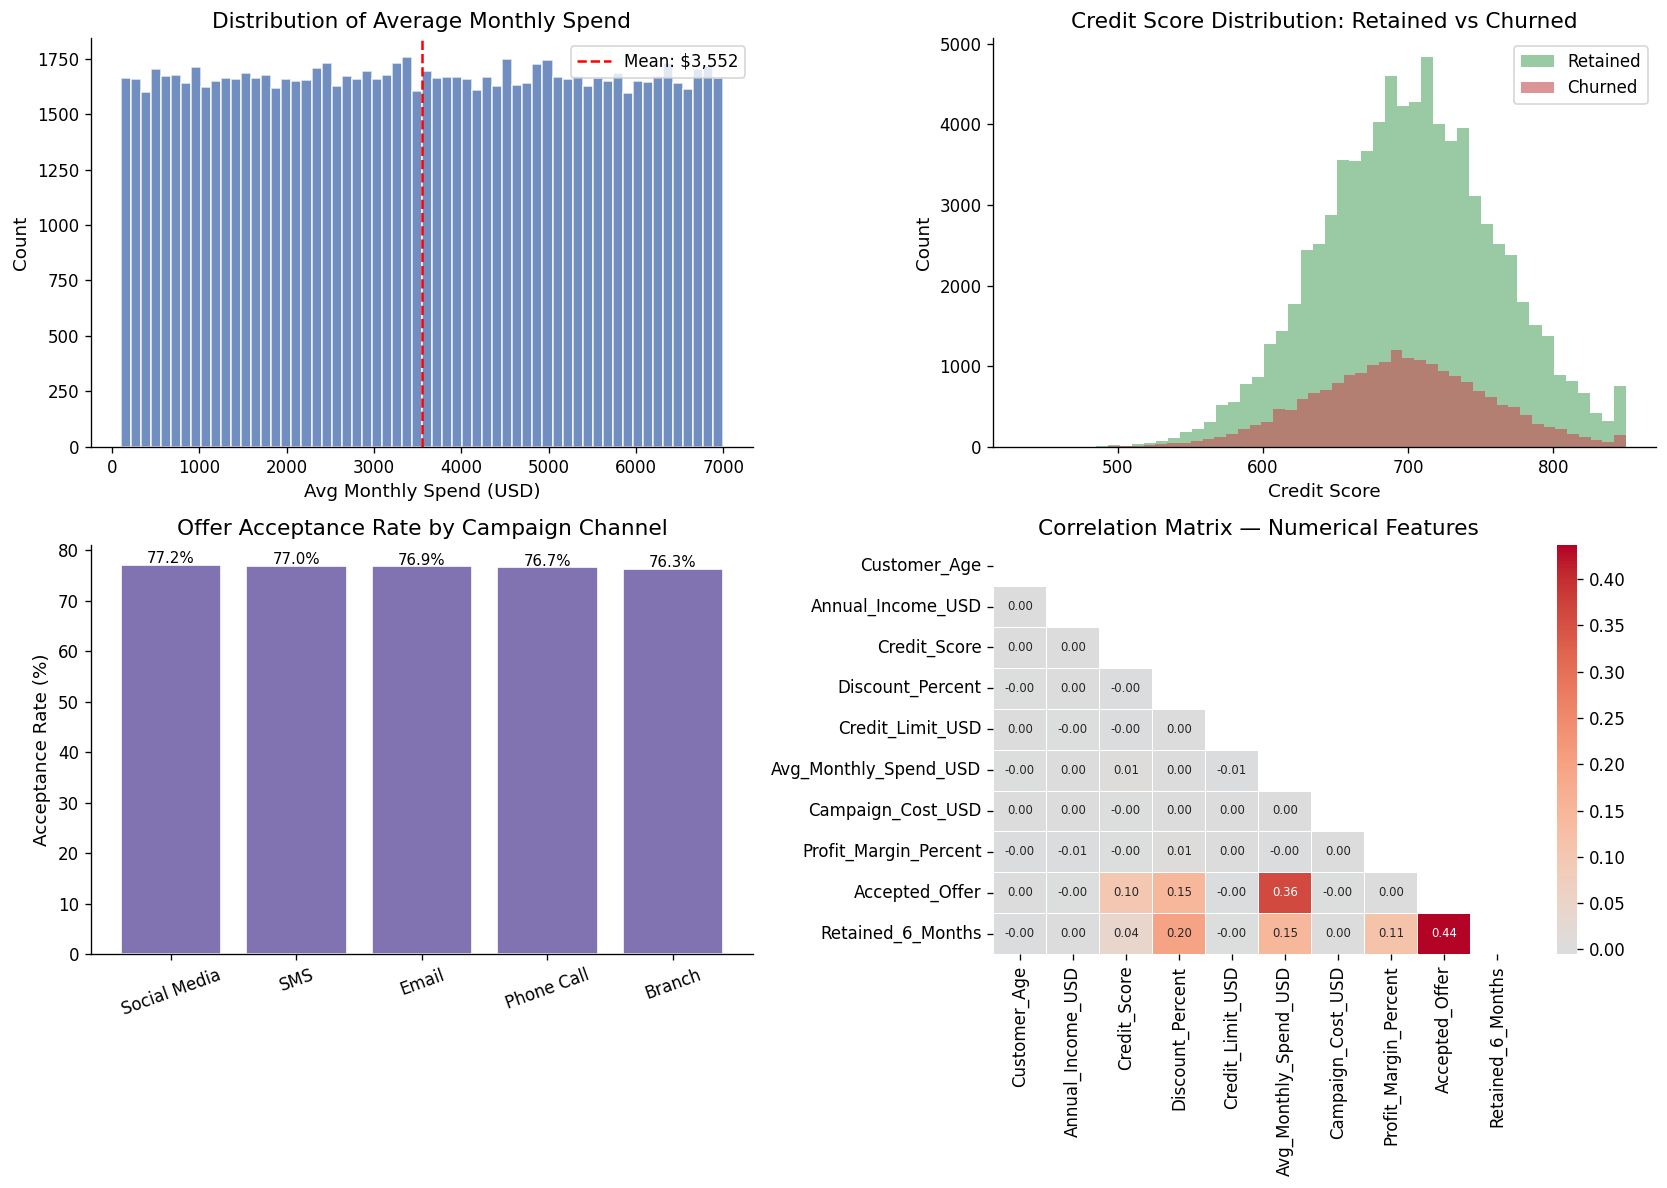

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of average monthly spend
axes[0, 0].hist(df_clean["Avg_Monthly_Spend_USD"], bins=60, color="#4C72B0",
                edgecolor="white", alpha=0.8)
axes[0, 0].set_xlabel("Avg Monthly Spend (USD)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of Average Monthly Spend")
axes[0, 0].axvline(df_clean["Avg_Monthly_Spend_USD"].mean(), color="red",
                   linestyle="--", label=f"Mean: ${df_clean['Avg_Monthly_Spend_USD'].mean():,.0f}")
axes[0, 0].legend()

# Credit score vs retention
retained = df_clean[df_clean["Retained_6_Months"] == 1]["Credit_Score"]
churned = df_clean[df_clean["Retained_6_Months"] == 0]["Credit_Score"]
axes[0, 1].hist(retained, bins=50, alpha=0.6, color="#55A868", label="Retained")
axes[0, 1].hist(churned, bins=50, alpha=0.6, color="#C44E52", label="Churned")
axes[0, 1].set_xlabel("Credit Score")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Credit Score Distribution: Retained vs Churned")
axes[0, 1].legend()

# Channel-level acceptance rate
ch_accept = (
    df_clean.groupby("Campaign_Channel")["Accepted_Offer"]
    .mean().mul(100).sort_values(ascending=False)
)
axes[1, 0].bar(ch_accept.index, ch_accept.values, color="#8172B2", edgecolor="white")
axes[1, 0].set_ylabel("Acceptance Rate (%)")
axes[1, 0].set_title("Offer Acceptance Rate by Campaign Channel")
axes[1, 0].tick_params(axis="x", rotation=20)
for i, val in enumerate(ch_accept.values):
    axes[1, 0].text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=9)

# Correlation heatmap
num_cols = ["Customer_Age", "Annual_Income_USD", "Credit_Score",
            "Discount_Percent", "Credit_Limit_USD", "Avg_Monthly_Spend_USD",
            "Campaign_Cost_USD", "Profit_Margin_Percent",
            "Accepted_Offer", "Retained_6_Months"]
corr_matrix = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1, 1], cmap="coolwarm",
            center=0, annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 7})
axes[1, 1].set_title("Correlation Matrix — Numerical Features")

plt.tight_layout()
plt.savefig("eda_distributions.png", bbox_inches="tight")
plt.show()

## EDA — Spend Distributions and Correlation

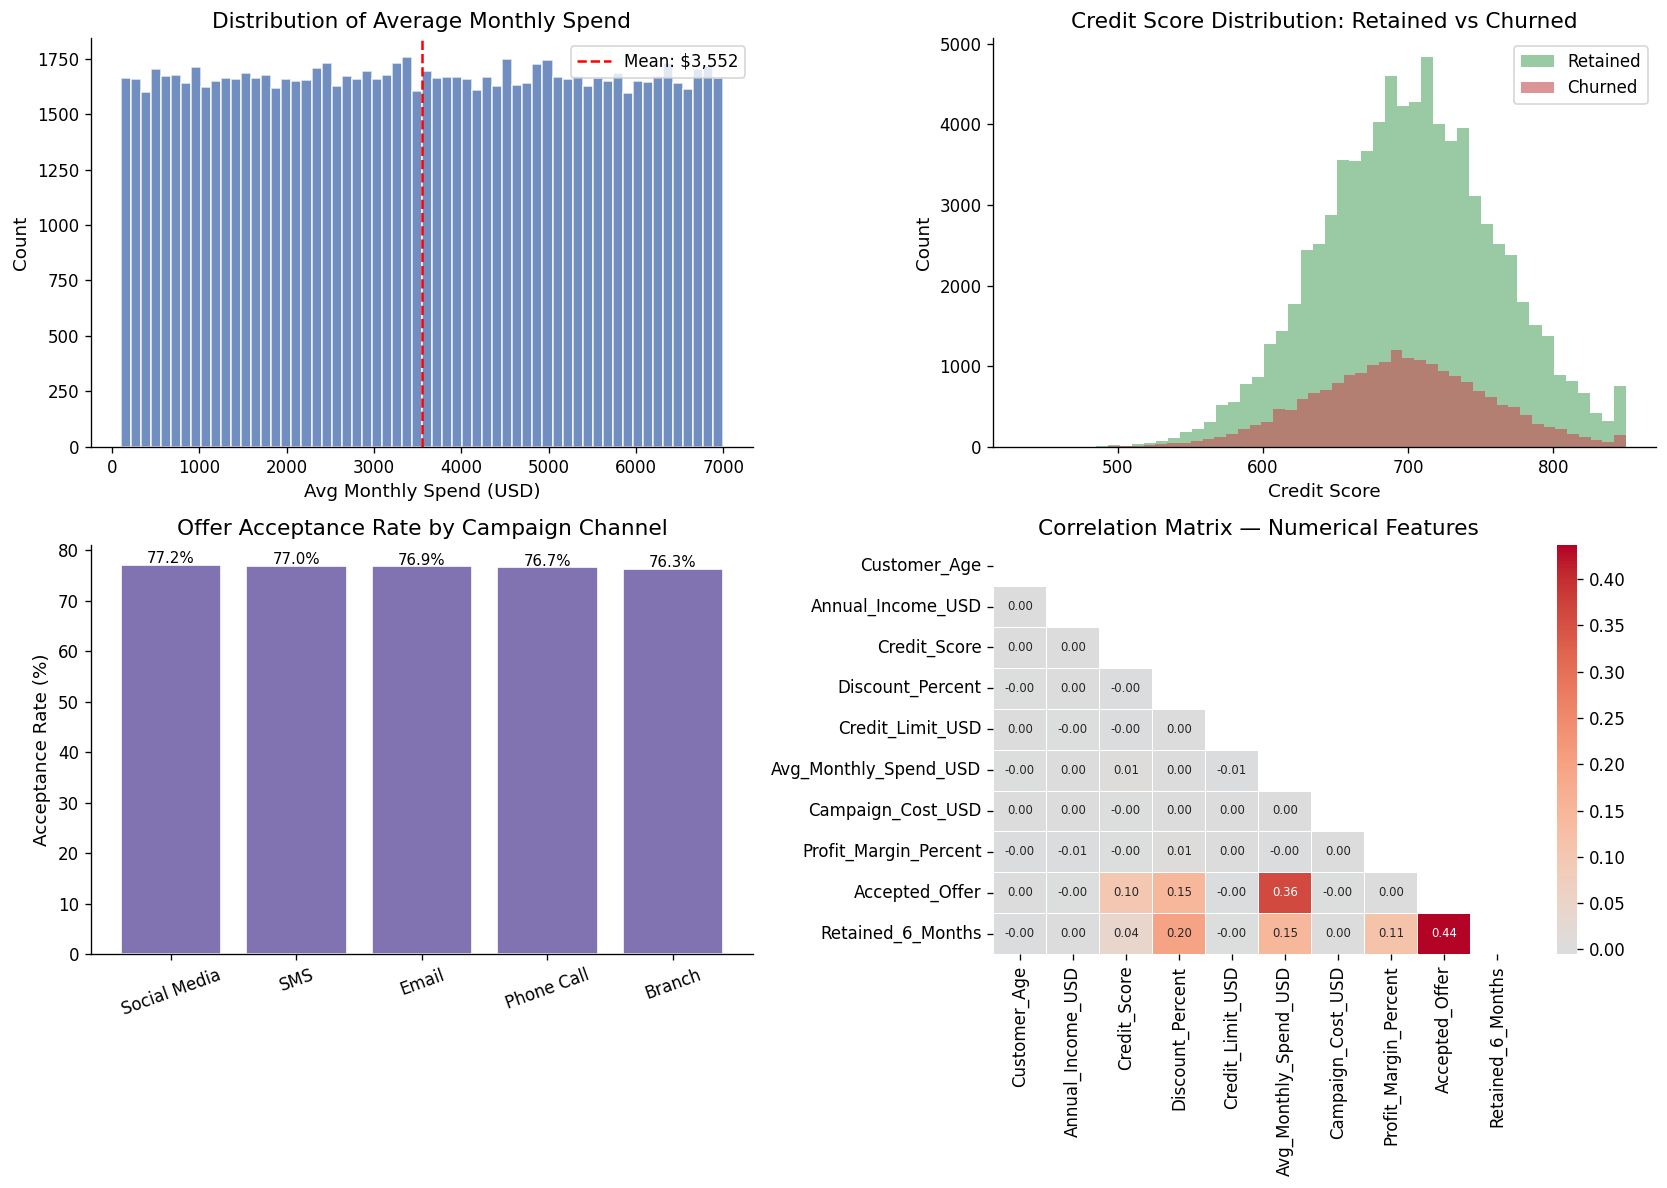

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of average monthly spend
axes[0, 0].hist(df_clean["Avg_Monthly_Spend_USD"], bins=60, color="#4C72B0",
                edgecolor="white", alpha=0.8)
axes[0, 0].set_xlabel("Avg Monthly Spend (USD)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of Average Monthly Spend")
axes[0, 0].axvline(df_clean["Avg_Monthly_Spend_USD"].mean(), color="red",
                   linestyle="--", label=f"Mean: ${df_clean['Avg_Monthly_Spend_USD'].mean():,.0f}")
axes[0, 0].legend()

# Credit score vs retention
retained = df_clean[df_clean["Retained_6_Months"] == 1]["Credit_Score"]
churned = df_clean[df_clean["Retained_6_Months"] == 0]["Credit_Score"]
axes[0, 1].hist(retained, bins=50, alpha=0.6, color="#55A868", label="Retained")
axes[0, 1].hist(churned, bins=50, alpha=0.6, color="#C44E52", label="Churned")
axes[0, 1].set_xlabel("Credit Score")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Credit Score Distribution: Retained vs Churned")
axes[0, 1].legend()

# Channel-level acceptance rate
ch_accept = (
    df_clean.groupby("Campaign_Channel")["Accepted_Offer"]
    .mean().mul(100).sort_values(ascending=False)
)
axes[1, 0].bar(ch_accept.index, ch_accept.values, color="#8172B2", edgecolor="white")
axes[1, 0].set_ylabel("Acceptance Rate (%)")
axes[1, 0].set_title("Offer Acceptance Rate by Campaign Channel")
axes[1, 0].tick_params(axis="x", rotation=20)
for i, val in enumerate(ch_accept.values):
    axes[1, 0].text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=9)

# Correlation heatmap
num_cols = ["Customer_Age", "Annual_Income_USD", "Credit_Score",
            "Discount_Percent", "Credit_Limit_USD", "Avg_Monthly_Spend_USD",
            "Campaign_Cost_USD", "Profit_Margin_Percent",
            "Accepted_Offer", "Retained_6_Months"]
corr_matrix = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1, 1], cmap="coolwarm",
            center=0, annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 7})
axes[1, 1].set_title("Correlation Matrix — Numerical Features")

plt.tight_layout()
plt.savefig("eda_distributions.png", bbox_inches="tight")
plt.show()

## Feature Engineering

Raw columns describe what a customer is. Engineered features describe what a customer does
and how that behavior predicts outcomes. Good features encode domain knowledge — the kind
a relationship manager would intuitively know about a customer.

Features we will create:

1. Spend_to_Income_Ratio: Monthly spend relative to income. A high ratio means the card
   is central to their financial life — these customers are harder to replace and more
   sensitive to disruptions.

2. Credit_Utilization: Avg monthly spend divided by credit limit. High utilization
   customers generate more interchange revenue and also carry higher churn risk if
   disappointed by the bank.

3. Income_Band: Bucketed income tiers aligned to the bank's segment thresholds.
   Useful as a non-linear categorical encoding of income.

4. Is_High_Value: Binary flag for customers above the 75th percentile in both income
   and monthly spend. These are the customers the bank must retain at all costs.

5. Offer_Discount_Group: Low vs medium vs high discount — tests whether the size
   of the incentive matters independently of offer type.

6. Age_Group: Generational cohorts. Gen Z (21-27), Millennial (28-43), Gen X (44-59),
   Boomer (60+). Each cohort has distinct digital behavior and financial priorities.

7. Campaign_Month_Sin / Cos: Cyclic encoding of campaign month to preserve the circular
   nature of the calendar (January is closer to December than to June).

In [15]:
class FeatureEngineer:
    """
    Builds and documents all derived features. Each method adds one logical feature group.
    """

    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.copy()

    def add_spend_ratios(self):
        # How central is this card to the customer's financial life?
        self.df["Spend_to_Income_Ratio"] = (
            self.df["Avg_Monthly_Spend_USD"] * 12 / self.df["Annual_Income_USD"]
        ).round(4)

        # What fraction of available credit is being used monthly?
        self.df["Credit_Utilization"] = (
            self.df["Avg_Monthly_Spend_USD"] / self.df["Credit_Limit_USD"]
        ).round(4)

    def add_income_band(self):
        # Bucket income into business-meaningful tiers
        bins = [0, 30_000, 60_000, 100_000, 200_000, np.inf]
        labels = ["Below 30K", "30K-60K", "60K-100K", "100K-200K", "Above 200K"]
        self.df["Income_Band"] = pd.cut(
            self.df["Annual_Income_USD"], bins=bins, labels=labels, right=False
        ).astype(str)

    def add_high_value_flag(self):
        # Customers in the top quartile of both income and spend
        income_75 = self.df["Annual_Income_USD"].quantile(0.75)
        spend_75 = self.df["Avg_Monthly_Spend_USD"].quantile(0.75)
        self.df["Is_High_Value"] = (
            (self.df["Annual_Income_USD"] >= income_75) &
            (self.df["Avg_Monthly_Spend_USD"] >= spend_75)
        ).astype(int)

    def add_discount_group(self):
        bins = [0, 10, 20, 100]
        labels = ["Low", "Medium", "High"]
        self.df["Offer_Discount_Group"] = pd.cut(
            self.df["Discount_Percent"], bins=bins, labels=labels, right=True
        ).astype(str)

    def add_age_group(self):
        bins = [20, 28, 44, 60, 100]
        labels = ["Gen Z", "Millennial", "Gen X", "Boomer"]
        self.df["Age_Group"] = pd.cut(
            self.df["Customer_Age"], bins=bins, labels=labels, right=False
        ).astype(str)

    def add_cyclic_month(self):
        # Encode month as sin/cos to preserve calendar circularity
        month = self.df["Campaign_Month"]
        self.df["Month_Sin"] = np.sin(2 * np.pi * month / 12)
        self.df["Month_Cos"] = np.cos(2 * np.pi * month / 12)

    def build_all(self):
        self.add_spend_ratios()
        self.add_income_band()
        self.add_high_value_flag()
        self.add_discount_group()
        self.add_age_group()
        self.add_cyclic_month()
        print("Feature engineering complete.")
        print(f"Dataset shape after engineering: {self.df.shape}")
        new_cols = [
            "Spend_to_Income_Ratio", "Credit_Utilization", "Income_Band",
            "Is_High_Value", "Offer_Discount_Group", "Age_Group", "Month_Sin", "Month_Cos"
        ]
        print("\nNew features added:")
        for col in new_cols:
            print(f"  {col}: sample = {self.df[col].iloc[0]}")
        return self.df


fe = FeatureEngineer(df_clean)
df_engineered = fe.build_all()

Feature engineering complete.
Dataset shape after engineering: (100000, 27)

New features added:
  Spend_to_Income_Ratio: sample = 0.6516
  Credit_Utilization: sample = 0.105
  Income_Band: sample = 30K-60K
  Is_High_Value: sample = 0
  Offer_Discount_Group: sample = High
  Age_Group: sample = Gen X
  Month_Sin: sample = -0.8660254037844386
  Month_Cos: sample = 0.5000000000000001


## Hypothesis Testing: Did the Retention Offer Actually Work?

This is the analytical core of the project. Before we build any model, we need to answer
the fundamental question the CFO will ask: "Did this campaign actually retain more customers
or would they have stayed anyway?"

We will run two tests:

### Test 1: Two-Sample Z-Test for Proportions (Retention Rate)

We compare the 6-month retention rate of the Cashback group (our highest-engagement treatment)
against the Balance Transfer group (lowest engagement, closest to a neutral offer — our control proxy).

Why a Z-test for proportions? Our outcome variable is binary (retained: 1, not retained: 0).
With n > 30 in each group, the Central Limit Theorem guarantees the sampling distribution of the
proportion is approximately normal. The Z-test is the appropriate tool for comparing two proportions.

Hypotheses:
- H0 (Null): The retention rate of the Cashback group equals the retention rate of
  the Balance Transfer group. Any observed difference is due to random sampling variation.
  H0: p_cashback = p_control
- H1 (Alternative): The Cashback group has a statistically higher retention rate.
  H1: p_cashback > p_control

Significance level (alpha): 0.05
We will reject H0 only if p-value < 0.05, meaning there is less than a 5% probability
of observing this difference by chance if H0 were true.

### Test 2: Chi-Square Test of Independence

We test whether Offer_Type and Retained_6_Months are statistically independent, across all
6 offer types simultaneously.

### Mathematical Formulation (Z-test for proportions):

         p_hat_1 - p_hat_2
Z = --------------------------------
    
    
    sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

Where p_pool = (x1 + x2) / (n1 + n2) is the pooled proportion under H0.


Primary Hypothesis Test
  A/B Test: Cashback vs Balance Transfer

Group A (Cashback):
  Sample Size (n_a) : 16,623
  Events (retained) : 13,353
  Retention Rate    : 0.8033 (80.33%)

Group B (Balance Transfer):
  Sample Size (n_b) : 16,501
  Events (retained) : 13,140
  Retention Rate    : 0.7963 (79.63%)

Pooled Proportion  : 0.7998
Standard Error     : 0.004397
Z-Statistic        : 1.5849
P-Value (one-tail) : 0.056491
95% CI for diff    : [-0.0016, 0.0156] (-0.16%, 1.56%)

Significance Level (alpha): 0.05

CONCLUSION: FAIL TO REJECT H0.
  The observed difference is within expected random variation.
  No statistically significant uplift detected.


Secondary Test: All Offer Types

  Chi-Square Test: Offer Type vs Retention (All Groups)

Contingency Table:
Retained_6_Months     0      1
Offer_Type                    
Balance Transfer   3361  13140
Cashback           3270  13353
Dining Rewards     3270  13363
Low Interest       3431  13304
Premium Lifestyle  3394  13337
Travel Rewards 

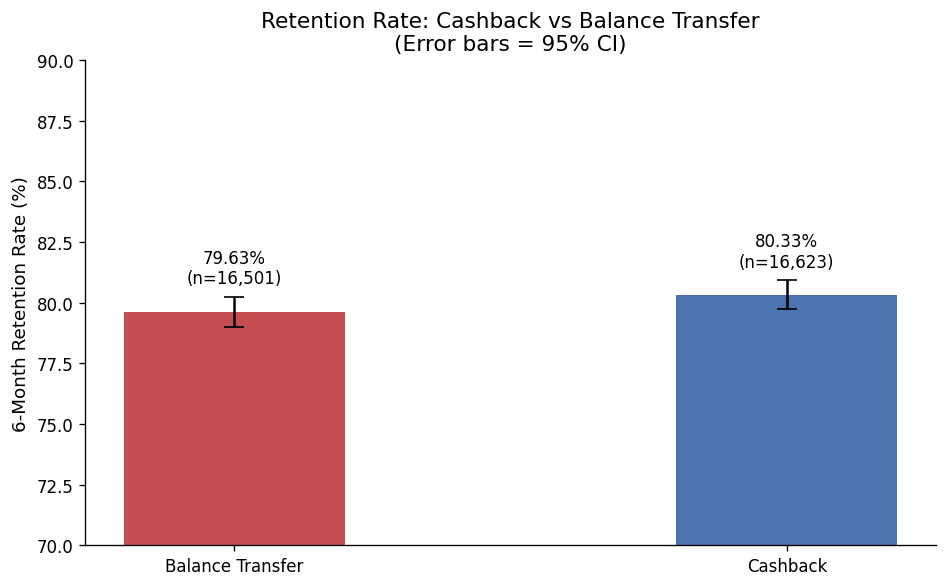

In [17]:
class ABTestAnalyzer:
    """
    Encapsulates A/B test logic for campaign retention analysis.
    Supports Z-test for proportions and Chi-square independence test.
    """

    def __init__(self, dataframe: pd.DataFrame, treatment_col: str, outcome_col: str):
        self.df = dataframe
        self.treatment_col = treatment_col
        self.outcome_col = outcome_col

    def z_test_proportions(self, group_a: str, group_b: str, alpha: float = 0.05):
        """
        Two-sample Z-test for proportions.
        group_a: treatment arm (e.g. 'Cashback')
        group_b: control arm  (e.g. 'Balance Transfer')
        """
        data_a = self.df[self.df[self.treatment_col] == group_a][self.outcome_col]
        data_b = self.df[self.df[self.treatment_col] == group_b][self.outcome_col]

        n_a, n_b = len(data_a), len(data_b)
        p_a = data_a.mean()  # retention rate in treatment group
        p_b = data_b.mean()  # retention rate in control group

        # Pooled proportion under H0
        p_pool = (data_a.sum() + data_b.sum()) / (n_a + n_b)

        # Standard error
        se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))

        # Z statistic
        z_stat = (p_a - p_b) / se

        # One-tailed p-value (H1: p_a > p_b)
        p_value = 1 - norm.cdf(z_stat)

        # 95% confidence interval for the difference
        diff = p_a - p_b
        margin = 1.96 * np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
        ci_lo = diff - margin
        ci_hi = diff + margin

        print("=" * 60)
        print(f"  A/B Test: {group_a} vs {group_b}")
        print("=" * 60)
        print(f"\nGroup A ({group_a}):")
        print(f"  Sample Size (n_a) : {n_a:,}")
        print(f"  Events (retained) : {data_a.sum():,}")
        print(f"  Retention Rate    : {p_a:.4f} ({p_a*100:.2f}%)")
        print(f"\nGroup B ({group_b}):")
        print(f"  Sample Size (n_b) : {n_b:,}")
        print(f"  Events (retained) : {data_b.sum():,}")
        print(f"  Retention Rate    : {p_b:.4f} ({p_b*100:.2f}%)")
        print(f"\nPooled Proportion  : {p_pool:.4f}")
        print(f"Standard Error     : {se:.6f}")
        print(f"Z-Statistic        : {z_stat:.4f}")
        print(f"P-Value (one-tail) : {p_value:.6f}")
        print(f"95% CI for diff    : [{ci_lo:.4f}, {ci_hi:.4f}] "
              f"({ci_lo*100:.2f}%, {ci_hi*100:.2f}%)")
        print(f"\nSignificance Level (alpha): {alpha}")

        if p_value < alpha:
            print(f"\nCONCLUSION: REJECT H0.")
            print(f"  The retention rate difference ({diff*100:.2f} percentage points) is")
            print(f"  statistically significant (p = {p_value:.6f} < {alpha}).")
            print(f"  The {group_a} offer genuinely improved retention above {group_b}.")
        else:
            print(f"\nCONCLUSION: FAIL TO REJECT H0.")
            print(f"  The observed difference is within expected random variation.")
            print(f"  No statistically significant uplift detected.")

        return {
            "z_stat": z_stat, "p_value": p_value, "p_a": p_a, "p_b": p_b,
            "diff": diff, "ci_lo": ci_lo, "ci_hi": ci_hi,
            "significant": p_value < alpha
        }

    def chi_square_independence(self, alpha: float = 0.05):
        """Test whether Offer_Type and retention outcome are independent."""
        contingency = pd.crosstab(
            self.df[self.treatment_col],
            self.df[self.outcome_col]
        )
        chi2, p_val, dof, expected = chi2_contingency(contingency)

        print("\n" + "=" * 60)
        print("  Chi-Square Test: Offer Type vs Retention (All Groups)")
        print("=" * 60)
        print("\nContingency Table:")
        print(contingency.to_string())
        print(f"\nChi-Square Statistic : {chi2:.4f}")
        print(f"Degrees of Freedom   : {dof}")
        print(f"P-Value              : {p_val:.6f}")

        if p_val < alpha:
            print(f"\nCONCLUSION: Offer type and retention are NOT independent (p < {alpha}).")
            print("  The type of offer received has a statistically significant relationship")
            print("  with whether a customer was retained.")
        else:
            print(f"\nCONCLUSION: No evidence of a relationship between offer type and retention.")

        return {"chi2": chi2, "p_value": p_val, "dof": dof}

    def plot_retention_comparison(self, group_a: str, group_b: str):
        """Visualize the retention rate comparison between two groups."""
        rates = (
            self.df[self.df[self.treatment_col].isin([group_a, group_b])]
            .groupby(self.treatment_col)["Retained_6_Months"]
            .agg(["mean", "count", "sum"])
            .reset_index()
        )
        rates.columns = ["Offer_Type", "Retention_Rate", "n", "retained"]
        rates["se"] = np.sqrt(
            rates["Retention_Rate"] * (1 - rates["Retention_Rate"]) / rates["n"]
        )
        rates["ci_95"] = 1.96 * rates["se"]
        rates["Retention_Rate_Pct"] = rates["Retention_Rate"] * 100

        fig, ax = plt.subplots(figsize=(8, 5))
        colors = ["#4C72B0" if o == group_a else "#C44E52" for o in rates["Offer_Type"]]
        bars = ax.bar(
            rates["Offer_Type"],
            rates["Retention_Rate_Pct"],
            color=colors,
            width=0.4,
            yerr=rates["ci_95"] * 100,
            capsize=6,
            error_kw={"elinewidth": 1.5}
        )
        ax.set_ylabel("6-Month Retention Rate (%)")
        ax.set_title(f"Retention Rate: {group_a} vs {group_b}\n(Error bars = 95% CI)")
        ax.set_ylim(70, 90)
        for bar, row in zip(bars, rates.itertuples()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{row.Retention_Rate_Pct:.2f}%\n(n={row.n:,})",
                    ha="center", va="bottom", fontsize=10)
        plt.tight_layout()
        plt.savefig("ab_test_chart.png", bbox_inches="tight")
        plt.show()


# Run the tests
ab_analyzer = ABTestAnalyzer(df_engineered, "Offer_Type", "Retained_6_Months")

print("\nPrimary Hypothesis Test")
z_results = ab_analyzer.z_test_proportions("Cashback", "Balance Transfer")

print("\n\nSecondary Test: All Offer Types")
chi_results = ab_analyzer.chi_square_independence()

# Visualize
ab_analyzer.plot_retention_comparison("Cashback", "Balance Transfer")

## Interpreting the Statistical Results

The Z-test result gives us a quantitative answer to the business question.

### What the P-Value Means in Plain English

If we ran this exact campaign 1,000 times on random splits of the same population, the p-value
tells us how many of those trials would produce a difference this large by pure chance, even if
the offer had zero real effect. A p-value below 0.05 (5%) means: "This difference would appear
by luck less than 5% of the time. It is more likely a real effect."

### Confidence Interval Interpretation

The 95% confidence interval for the retention rate difference tells us the range within which
the true population-level effect most likely falls. If the interval does not include zero,
we are confident the effect is real and directionally consistent.

### Business Translation

- If significant: The Cashback offer adds measurable retention lift. Deploying it broadly
  is statistically justified. The bank should calculate the ROI — does the campaign cost
  pay for itself in prevented churn revenue?

- If not significant: The observed difference may reflect random variation in which customers
  happened to be placed in each group. The bank should not scale up Cashback spending based
  on this data alone — a larger or better-controlled trial is warranted.

The Chi-Square test, covering all six offer types, tests whether offer type matters at all
to retention, regardless of which specific offer performs best. A significant chi-square
result means at least one offer type is meaningfully different from the others.

Full A/B Group Summary (all offer types):
                       n  accepted  retained    avg_spend  avg_campaign_cost  acceptance_rate  retention_rate
Offer_Type                                                                                                   
Dining Rewards     16633     12744     13363  3544.008918          79.899052            76.62           80.34
Cashback           16623     12791     13353  3578.812415          80.187200            76.95           80.33
Travel Rewards     16777     12922     13410  3547.383796          79.892720            77.02           79.93
Premium Lifestyle  16731     12836     13337  3555.814548          80.222407            76.72           79.71
Balance Transfer   16501     12699     13140  3542.791853          79.853853            76.96           79.63
Low Interest       16735     12820     13304  3542.993118          80.054287            76.61           79.50


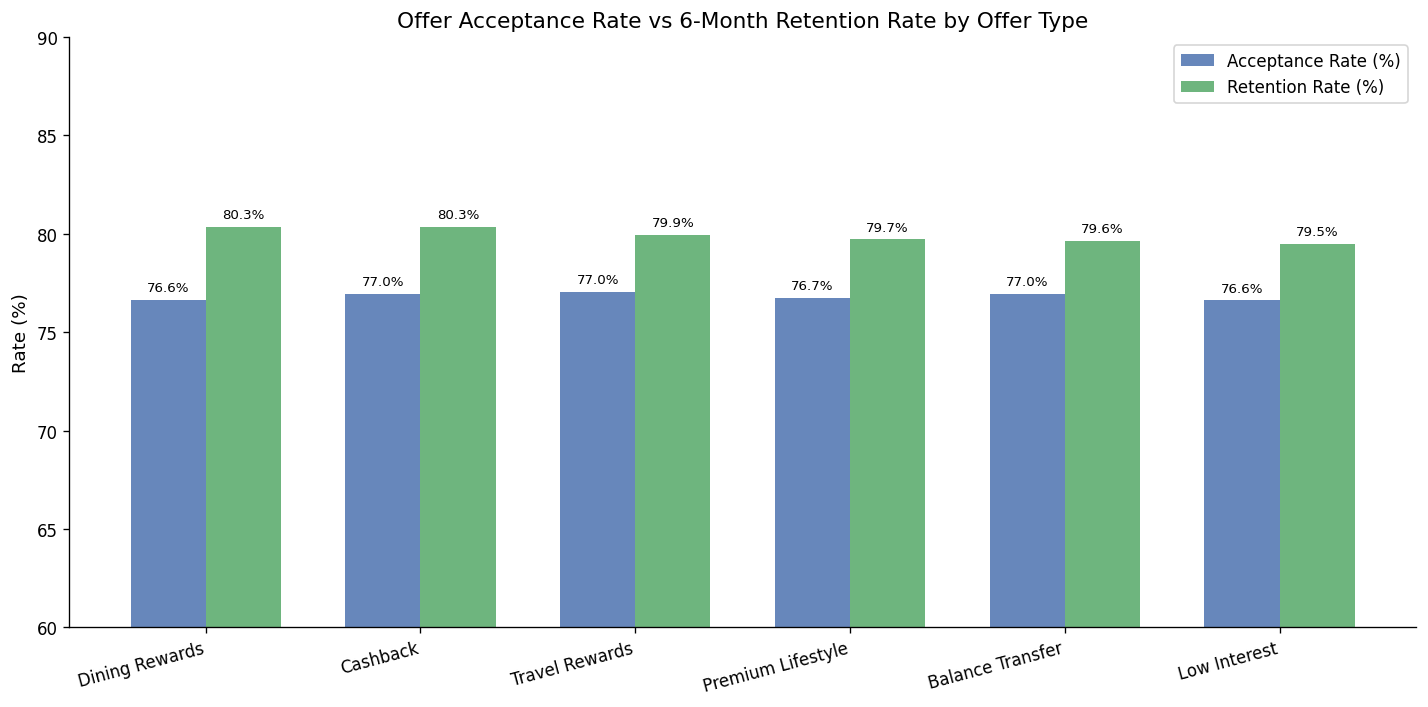

In [19]:
# Full offer-level retention and acceptance rate comparison
group_summary = (
    df_engineered.groupby("Offer_Type")
    .agg(
        n=("Account_ID", "count"),
        accepted=("Accepted_Offer", "sum"),
        retained=("Retained_6_Months", "sum"),
        avg_spend=("Avg_Monthly_Spend_USD", "mean"),
        avg_campaign_cost=("Campaign_Cost_USD", "mean"),
    )
    .assign(
        acceptance_rate=lambda x: (x["accepted"] / x["n"] * 100).round(2),
        retention_rate=lambda x: (x["retained"] / x["n"] * 100).round(2),
    )
    .sort_values("retention_rate", ascending=False)
)

print("Full A/B Group Summary (all offer types):")
print(group_summary.to_string())

# Visual: dual-axis comparison
fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(group_summary))
width = 0.35

bars1 = ax1.bar(x - width/2, group_summary["acceptance_rate"],
                width, label="Acceptance Rate (%)", color="#4C72B0", alpha=0.85)
bars2 = ax1.bar(x + width/2, group_summary["retention_rate"],
                width, label="Retention Rate (%)", color="#55A868", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(group_summary.index, rotation=15, ha="right")
ax1.set_ylabel("Rate (%)")
ax1.set_title("Offer Acceptance Rate vs 6-Month Retention Rate by Offer Type")
ax1.legend()
ax1.set_ylim(60, 90)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("group_comparison.png", bbox_inches="tight")
plt.show()

## Data Preprocessing

Before building our predictive model, we need to prepare the data in a way that a machine
learning algorithm can consume. This involves four key steps:

1. Feature Selection: We choose predictors that are available at the time of prediction
   (i.e., before the campaign is executed). We must be careful to avoid data leakage —
   we cannot use Retained_6_Months to predict Accepted_Offer, for example, since retention
   is a future outcome we would not know at scoring time.

2. Encoding: Logistic Regression requires all inputs to be numeric. We use Label Encoding
   for ordinal-ish categoricals and One-Hot Encoding for nominal ones.

3. Scaling: Logistic Regression is sensitive to feature magnitude. A variable measured in
   tens of thousands (income) will dominate one measured in units (age) unless we scale.
   We use StandardScaler to bring all features to zero mean and unit variance.

4. Train-Test Split: We hold out 20% of the data for final evaluation. We stratify the
   split on the target variable (Accepted_Offer) to ensure the class distribution is
   preserved in both sets.

Our prediction target: Accepted_Offer (1 = accepted, 0 = did not accept).

This is the most directly actionable prediction — before running a campaign, the bank
wants to know which customers are likely to engage so they can personalize the outreach.

In [20]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature groups
NUMERIC_FEATURES = [
    "Customer_Age", "Annual_Income_USD", "Credit_Score", "Discount_Percent",
    "Credit_Limit_USD", "Avg_Monthly_Spend_USD", "Profit_Margin_Percent",
    "Spend_to_Income_Ratio", "Credit_Utilization", "Is_High_Value",
    "Month_Sin", "Month_Cos"
]

CATEGORICAL_FEATURES = [
    "Offer_Type", "Campaign_Channel", "Region", "Customer_Segment",
    "Income_Band", "Offer_Discount_Group", "Age_Group"
]

TARGET = "Accepted_Offer"

# Subset to relevant columns only
feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df_engineered[feature_cols].copy()
y = df_engineered[TARGET].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).mul(100).round(2).to_string()}")

# Build preprocessing pipeline
# Numeric: standard scale
# Categorical: one-hot encode (drop first to avoid multicollinearity in logit)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
         CATEGORICAL_FEATURES),
    ]
)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]:,} samples")
print(f"Test set : {X_test.shape[0]:,} samples")
print(f"\nTrain target distribution: {y_train.mean()*100:.1f}% positive")
print(f"Test  target distribution: {y_test.mean()*100:.1f}% positive")

# Fit preprocessor on train only — critical for preventing leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nProcessed train matrix shape: {X_train_processed.shape}")

Feature matrix shape: (100000, 19)
Target distribution:
Accepted_Offer
1    76.81
0    23.19

Train set: 80,000 samples
Test set : 20,000 samples

Train target distribution: 76.8% positive
Test  target distribution: 76.8% positive

Processed train matrix shape: (80000, 38)


## Predictive Modeling: Logistic Regression

We choose Logistic Regression as our primary model for offer acceptance prediction.

### Why Logistic Regression

1. Interpretability: Each coefficient directly tells us the log-odds contribution of
   a feature, which translates to a clear business story ("a customer with a higher credit
   score is X% more likely to accept the offer").

2. Calibrated Probabilities: Logistic Regression naturally outputs probabilities between
   0 and 1 via the sigmoid function. The bank can use these scores for customer ranking
   and tiered outreach strategies.

3. Baseline Requirement: In most enterprise settings, a simpler model that performs
   adequately is preferred over a complex one that performs marginally better.
   Logistic Regression is the de facto baseline in campaign scoring.

4. Regulatory Friendliness: In financial services, model explainability is often a
   regulatory requirement. Logistic Regression satisfies this.

### The Sigmoid Function

The model outputs:

   P(Accepted_Offer = 1) = 1 / (1 + exp(-z))

where z = b0 + b1*x1 + b2*x2 + ... + bn*xn is the linear combination of features.

As z → +infinity, P → 1. As z → -infinity, P → 0.
The decision boundary is at P = 0.5, i.e., z = 0.

The coefficients b1..bn represent the change in log-odds of acceptance per unit increase
in each feature. A positive coefficient means the feature increases acceptance probability.

Model training complete.

Model Evaluation Report
----------------------------------------
  Accuracy  : 0.6959
  Precision : 0.8926
  Recall    : 0.6868
  F1 Score  : 0.7763
  ROC AUC   : 0.7731

Classification Report:
              precision    recall  f1-score   support

Not Accepted       0.41      0.73      0.53      4638
    Accepted       0.89      0.69      0.78     15362

    accuracy                           0.70     20000
   macro avg       0.65      0.71      0.65     20000
weighted avg       0.78      0.70      0.72     20000


Confusion Matrix Breakdown:
  True Positives (TP = correctly predicted acceptors)  : 10,551
  True Negatives (TN = correctly predicted rejectors)  : 3,368
  False Positives (FP = predicted accept, actually not): 1,270
  False Negatives (FN = predicted reject, actually did): 4,811

  Business Note:
  False Negatives are costly — we miss potential acceptors and waste
  opportunities. High Recall is more valuable than high Precision here.
  False Posi

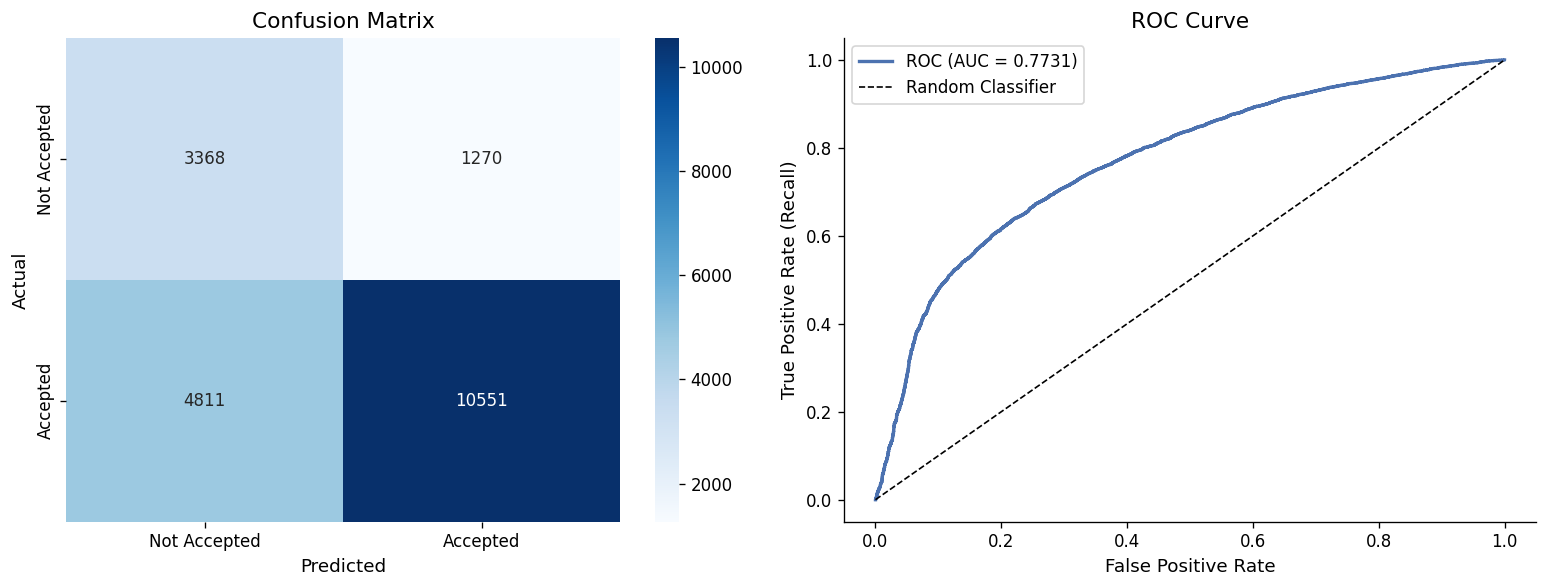

In [22]:
class RetentionPredictor:
    """
    End-to-end predictive model for offer acceptance.
    Wraps Logistic Regression with full evaluation and serialization.
    """

    def __init__(self, preprocessor, C=1.0, max_iter=500, random_state=42):
        self.preprocessor = preprocessor
        self.model = LogisticRegression(
            C=C,               # Inverse regularization strength; smaller = stronger L2
            max_iter=max_iter,
            random_state=random_state,
            solver="lbfgs",    # Efficient for medium-sized datasets
            class_weight="balanced"  # Compensates for mild class imbalance
        )
        self.pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", self.model)
        ])

    def fit(self, X_train, y_train):
        self.pipeline.fit(X_train, y_train)
        print("Model training complete.")

    def evaluate(self, X_test, y_test, threshold=0.5):
        y_pred_proba = self.pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba >= threshold).astype(int)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_pred_proba)
        cm = confusion_matrix(y_test, y_pred)

        print("\nModel Evaluation Report")
        print("-" * 40)
        print(f"  Accuracy  : {acc:.4f}")
        print(f"  Precision : {prec:.4f}")
        print(f"  Recall    : {rec:.4f}")
        print(f"  F1 Score  : {f1:.4f}")
        print(f"  ROC AUC   : {roc:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=["Not Accepted", "Accepted"]))

        return {
            "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "roc_auc": roc, "confusion_matrix": cm,
            "y_pred_proba": y_pred_proba
        }

    def plot_evaluation(self, X_test, y_test, metrics: dict):
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # Confusion matrix
        cm = metrics["confusion_matrix"]
        sns.heatmap(cm, annot=True, fmt="d", ax=axes[0], cmap="Blues",
                    xticklabels=["Not Accepted", "Accepted"],
                    yticklabels=["Not Accepted", "Accepted"])
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")
        axes[0].set_title("Confusion Matrix")

        # Business context note on confusion matrix
        tn, fp, fn, tp = cm.ravel()
        print(f"\nConfusion Matrix Breakdown:")
        print(f"  True Positives (TP = correctly predicted acceptors)  : {tp:,}")
        print(f"  True Negatives (TN = correctly predicted rejectors)  : {tn:,}")
        print(f"  False Positives (FP = predicted accept, actually not): {fp:,}")
        print(f"  False Negatives (FN = predicted reject, actually did): {fn:,}")
        print(f"\n  Business Note:")
        print(f"  False Negatives are costly — we miss potential acceptors and waste")
        print(f"  opportunities. High Recall is more valuable than high Precision here.")
        print(f"  False Positives mean we spend campaign budget on disinterested customers.")

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, metrics["y_pred_proba"])
        axes[1].plot(fpr, tpr, color="#4C72B0", lw=2,
                     label=f"ROC (AUC = {metrics['roc_auc']:.4f})")
        axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate (Recall)")
        axes[1].set_title("ROC Curve")
        axes[1].legend()

        plt.tight_layout()
        plt.savefig("model_evaluation.png", bbox_inches="tight")
        plt.show()

    def save(self, path: str):
        joblib.dump(self.pipeline, path)
        print(f"Model pipeline saved to: {path}")

    def load(self, path: str):
        self.pipeline = joblib.load(path)
        print(f"Model pipeline loaded from: {path}")

    def predict_single(self, customer_dict: dict):
        """Predict acceptance probability for a single customer record."""
        input_df = pd.DataFrame([customer_dict])
        proba = self.pipeline.predict_proba(input_df)[:, 1][0]
        return round(proba, 4)


# Train and evaluate
predictor = RetentionPredictor(preprocessor)
predictor.fit(X_train, y_train)
metrics = predictor.evaluate(X_test, y_test)
predictor.plot_evaluation(X_test, y_test, metrics)

5-Fold Stratified Cross-Validation Results:
  Accuracy : 0.6992 (+/- 0.0019)
  F1 Score : 0.7785 (+/- 0.0015)
  ROC AUC  : 0.7762 (+/- 0.0047)

Top 20 Feature Coefficients (by absolute magnitude):
                      Feature  Coefficient
        Avg_Monthly_Spend_USD     1.054635
             Discount_Percent     0.454414
                 Credit_Score     0.289489
              Age_Group_Gen Z    -0.120546
         Age_Group_Millennial    -0.111667
     Offer_Discount_Group_Low     0.058029
     Customer_Segment_Student    -0.053441
         Campaign_Channel_SMS     0.041184
Campaign_Channel_Social Media     0.039919
                 Customer_Age    -0.038660
              Age_Group_Gen X    -0.037757
  Offer_Discount_Group_Medium     0.036411
  Campaign_Channel_Phone Call     0.034896
 Customer_Segment_Mass Market    -0.033534
        Income_Band_Below 30K    -0.031272
       Campaign_Channel_Email     0.031128
    Offer_Type_Dining Rewards    -0.024233
         Customer_Segment_HNI

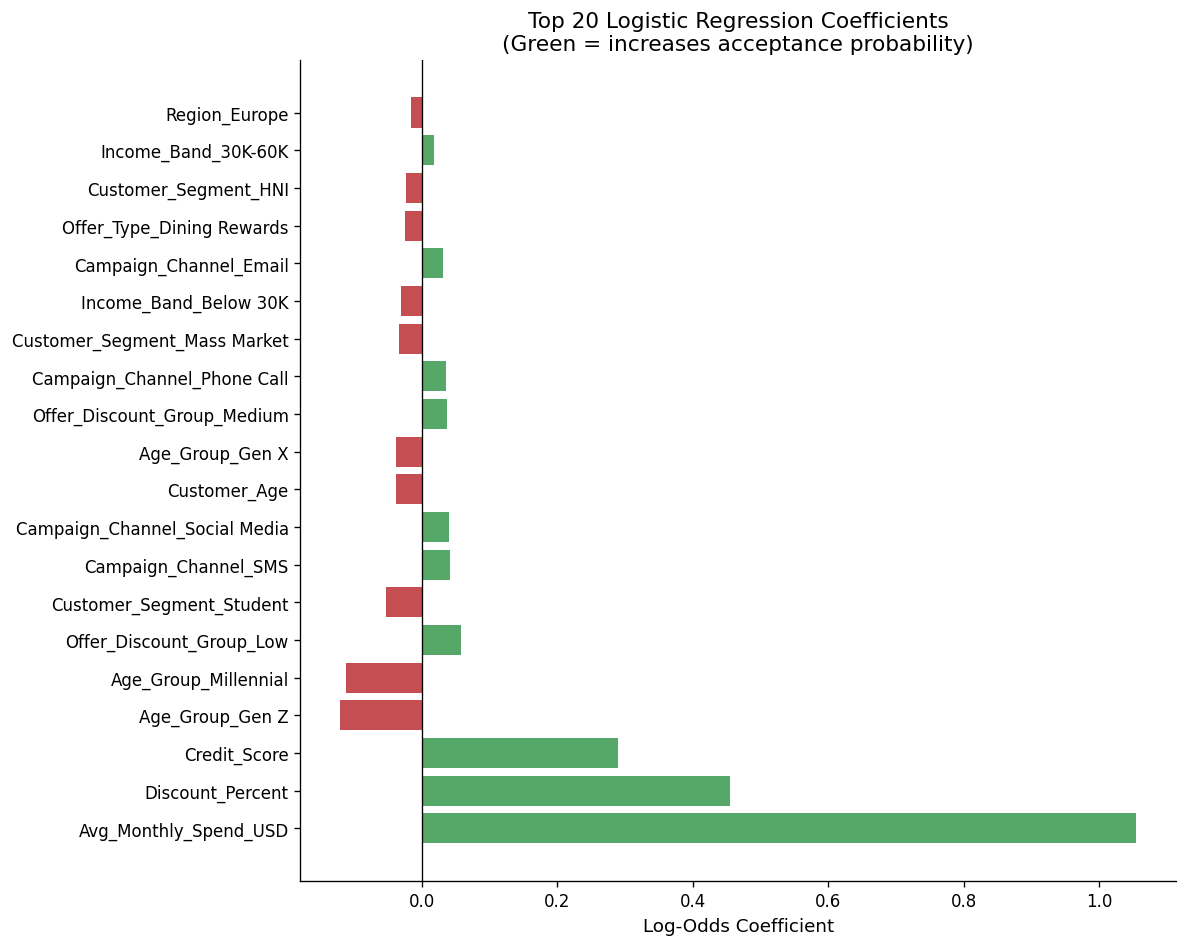

In [24]:
# 5-fold stratified cross-validation for stable performance estimates
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use a fresh pipeline for CV to avoid any leakage from the already-fit preprocessor
pipeline_for_cv = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
             CATEGORICAL_FEATURES),
        ]
    )),
    ("classifier", LogisticRegression(
        C=1.0, max_iter=500, random_state=42, solver="lbfgs", class_weight="balanced"
    ))
])

cv_results = cross_validate(
    pipeline_for_cv, X, y,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True
)

print("5-Fold Stratified Cross-Validation Results:")
print(f"  Accuracy : {cv_results['test_accuracy'].mean():.4f} "
      f"(+/- {cv_results['test_accuracy'].std():.4f})")
print(f"  F1 Score : {cv_results['test_f1'].mean():.4f} "
      f"(+/- {cv_results['test_f1'].std():.4f})")
print(f"  ROC AUC  : {cv_results['test_roc_auc'].mean():.4f} "
      f"(+/- {cv_results['test_roc_auc'].std():.4f})")

# Feature coefficient interpretation
# Get feature names after one-hot encoding
ohe = predictor.pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + cat_feature_names

coefficients = predictor.pipeline.named_steps["classifier"].coef_[0]
coef_df = (
    pd.DataFrame({"Feature": all_feature_names, "Coefficient": coefficients})
    .assign(Abs_Coef=lambda x: x["Coefficient"].abs())
    .sort_values("Abs_Coef", ascending=False)
    .head(20)
)

print("\nTop 20 Feature Coefficients (by absolute magnitude):")
print(coef_df[["Feature", "Coefficient"]].to_string(index=False))

# Visualize top coefficients
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#55A868" if c > 0 else "#C44E52" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Log-Odds Coefficient")
ax.set_title("Top 20 Logistic Regression Coefficients\n(Green = increases acceptance probability)")
plt.tight_layout()
plt.savefig("coefficients.png", bbox_inches="tight")
plt.show()

## Additional Business Insights

The model and tests together tell a story. Now we translate the statistical output into
business language that a Head of Marketing or Chief Risk Officer can act on.

### 1. Offer Sensitivity by Segment
Not every customer responds equally to the same offer. High-Net-Worth (HNI) customers may
respond more to lifestyle and status-linked offers, while SME customers are often motivated
by cash flow benefits like cashback or low interest. Mass market customers tend to be most
responsive to discount depth.

### 2. High-Value Customers at Risk
Customers with high spend-to-income ratios but declining recent activity represent a churn
signal the model can flag proactively. These customers have demonstrated that the card matters
to them — a targeted offer at the right moment is more likely to re-engage them than a
generic campaign.

### 3. Channel Efficiency
Not all channels are equal. The model's channel-level coefficients reveal which delivery
mechanism is associated with higher acceptance probability, allowing the bank to shift
budget toward higher-ROI touchpoints.

### 4. Campaign Timing
The cyclic month features capture seasonality — certain months see higher acceptance,
likely aligned with business cycle events like fiscal year starts or holiday seasons.
Campaigns timed to these peaks would benefit from natural customer openness to financial
decisions.

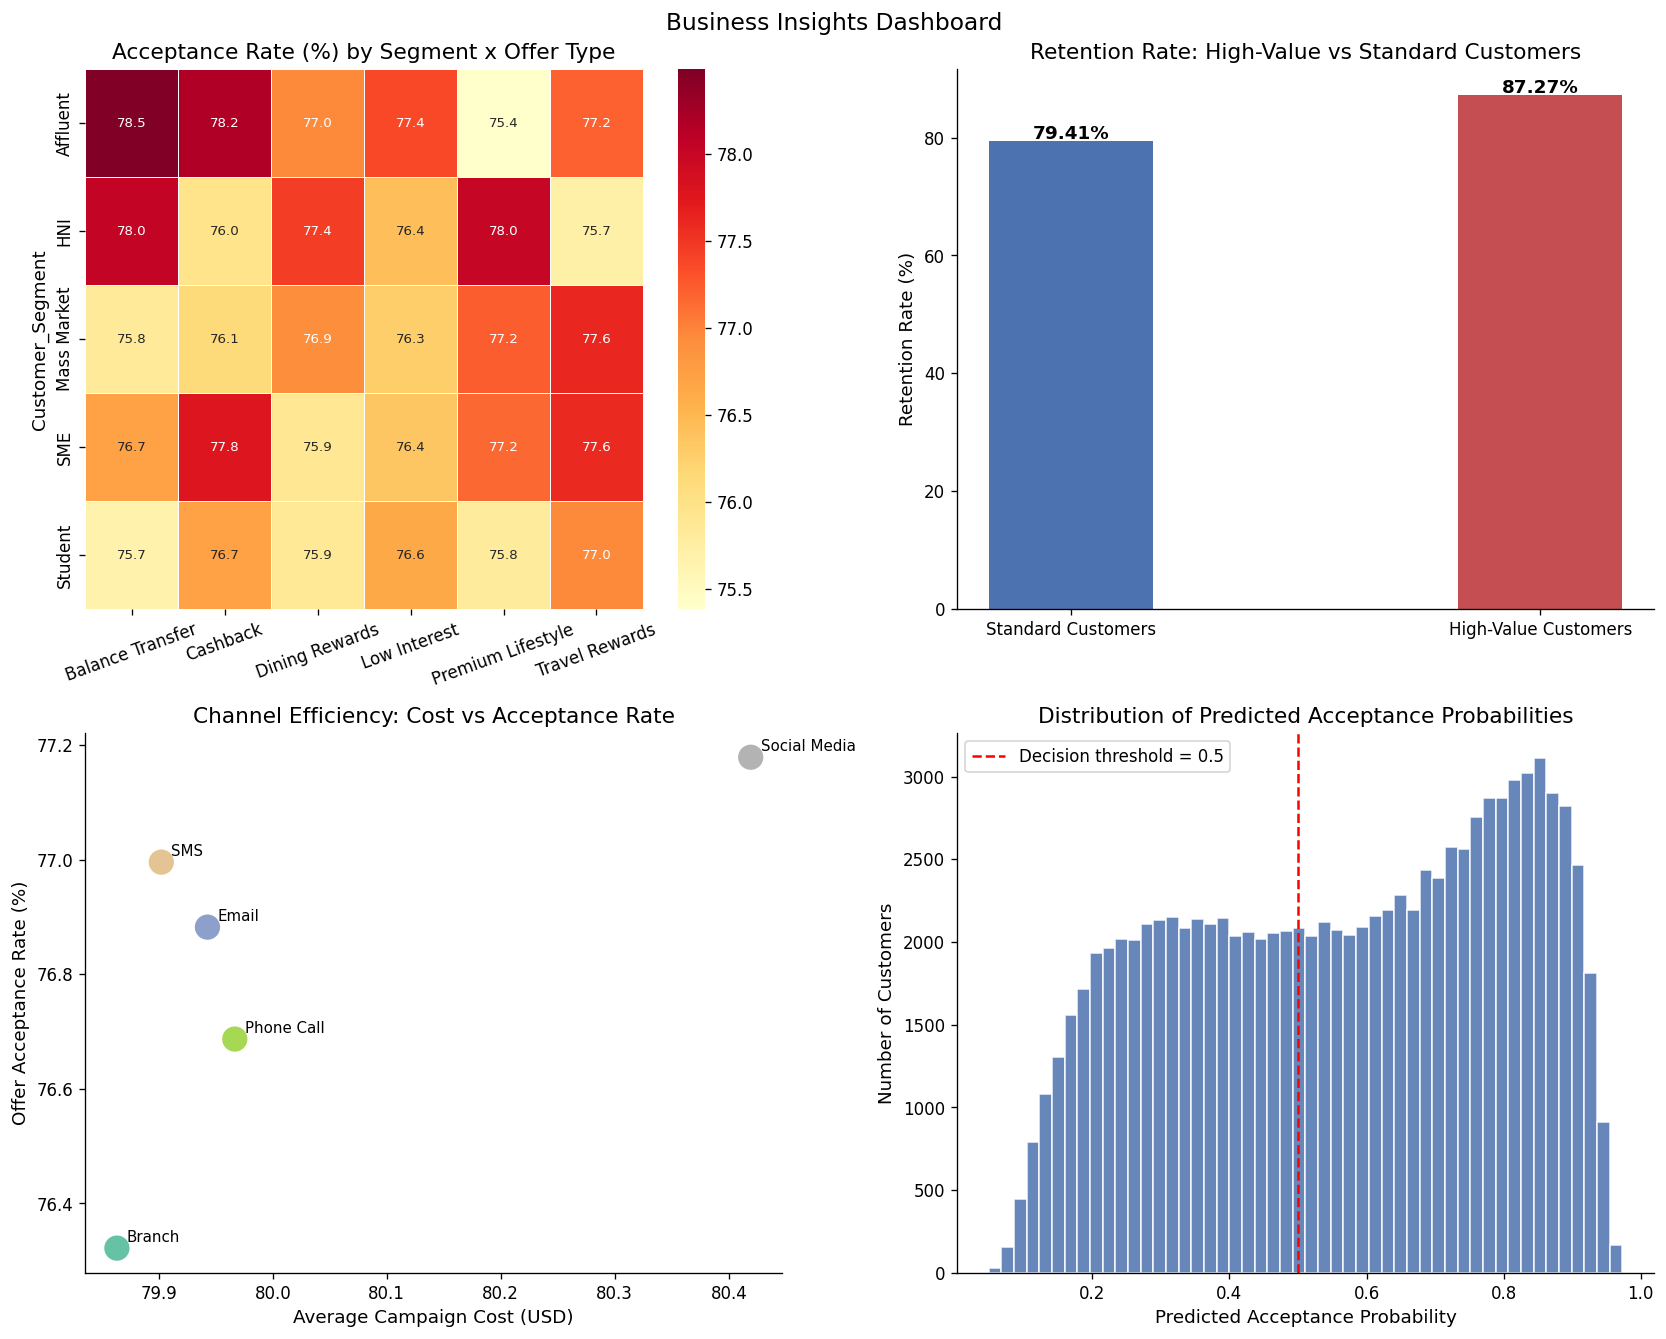

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Acceptance rate by segment and offer type (heatmap)
pivot_accept = df_engineered.pivot_table(
    values="Accepted_Offer",
    index="Customer_Segment",
    columns="Offer_Type",
    aggfunc="mean"
) * 100

sns.heatmap(pivot_accept, ax=axes[0, 0], annot=True, fmt=".1f",
            cmap="YlOrRd", linewidths=0.3, annot_kws={"size": 8})
axes[0, 0].set_title("Acceptance Rate (%) by Segment x Offer Type")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=20)

# 2. High-value customers: retention vs non-high-value
hv_compare = (
    df_engineered.groupby("Is_High_Value")["Retained_6_Months"]
    .agg(["mean", "count"])
    .reset_index()
)
hv_compare["Retention_Rate_Pct"] = hv_compare["mean"] * 100
hv_labels = ["Standard Customers", "High-Value Customers"]
colors = ["#4C72B0", "#C44E52"]
axes[0, 1].bar(hv_labels, hv_compare["Retention_Rate_Pct"], color=colors, width=0.35)
axes[0, 1].set_ylabel("Retention Rate (%)")
axes[0, 1].set_title("Retention Rate: High-Value vs Standard Customers")
for i, val in enumerate(hv_compare["Retention_Rate_Pct"]):
    axes[0, 1].text(i, val + 0.3, f"{val:.2f}%", ha="center", fontsize=11, fontweight="bold")

# 3. Average campaign cost vs acceptance rate by channel
channel_metrics = (
    df_engineered.groupby("Campaign_Channel")
    .agg(
        acceptance_rate=("Accepted_Offer", "mean"),
        avg_cost=("Campaign_Cost_USD", "mean")
    )
    .reset_index()
)
channel_metrics["acceptance_rate_pct"] = channel_metrics["acceptance_rate"] * 100
scatter = axes[1, 0].scatter(
    channel_metrics["avg_cost"],
    channel_metrics["acceptance_rate_pct"],
    s=200, c=range(len(channel_metrics)), cmap="Set2", zorder=3
)
for _, row in channel_metrics.iterrows():
    axes[1, 0].annotate(
        row["Campaign_Channel"],
        (row["avg_cost"], row["acceptance_rate_pct"]),
        xytext=(6, 4), textcoords="offset points", fontsize=9
    )
axes[1, 0].set_xlabel("Average Campaign Cost (USD)")
axes[1, 0].set_ylabel("Offer Acceptance Rate (%)")
axes[1, 0].set_title("Channel Efficiency: Cost vs Acceptance Rate")

# 4. Predicted acceptance probability distribution
y_pred_proba_all = predictor.pipeline.predict_proba(X)[:, 1]
axes[1, 1].hist(y_pred_proba_all, bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1, 1].axvline(0.5, color="red", linestyle="--", label="Decision threshold = 0.5")
axes[1, 1].set_xlabel("Predicted Acceptance Probability")
axes[1, 1].set_ylabel("Number of Customers")
axes[1, 1].set_title("Distribution of Predicted Acceptance Probabilities")
axes[1, 1].legend()

plt.tight_layout()
plt.suptitle("Business Insights Dashboard", fontsize=14, y=1.01)
plt.savefig("business_insights.png", bbox_inches="tight")
plt.show()

## Recommendation Engine

In [27]:
class RetentionRecommendationEngine:
    """
    Generates next-best-action recommendations for each customer
    based on their predicted acceptance probability and customer profile.
    """

    def __init__(self, predictor, data: pd.DataFrame, feature_cols: list):
        self.predictor = predictor
        self.df = data.copy()
        self.feature_cols = feature_cols

    def score_all_customers(self):
        X_all = self.df[self.feature_cols]
        self.df["Acceptance_Probability"] = (
            self.predictor.pipeline.predict_proba(X_all)[:, 1].round(4)
        )
        return self

    def assign_propensity_tier(self):
        def tier(p):
            if p >= 0.85:
                return "Hot Lead"
            elif p >= 0.70:
                return "Warm Lead"
            elif p >= 0.50:
                return "Cold Lead"
            else:
                return "Not Likely"

        self.df["Propensity_Tier"] = self.df["Acceptance_Probability"].apply(tier)
        return self

    def assign_recommended_action(self):
        conditions = [
            (self.df["Propensity_Tier"] == "Hot Lead") & (self.df["Is_High_Value"] == 1),
            (self.df["Propensity_Tier"] == "Hot Lead") & (self.df["Is_High_Value"] == 0),
            (self.df["Propensity_Tier"] == "Warm Lead"),
            (self.df["Propensity_Tier"] == "Cold Lead"),
            (self.df["Propensity_Tier"] == "Not Likely"),
        ]
        actions = [
            "Priority Outreach: Premium Offer + Dedicated RM Call",
            "Digital Outreach: Cashback or Travel Rewards Offer",
            "Email Campaign: Dining Rewards or Low Interest Offer",
            "SMS Nudge: Discount-Heavy Offer",
            "No Campaign: Include in Next Cycle Review",
        ]
        self.df["Recommended_Action"] = np.select(conditions, actions, default="Review Required")
        return self

    def generate_report(self):
        tier_summary = (
            self.df.groupby("Propensity_Tier")
            .agg(
                customers=("Account_ID", "count"),
                avg_probability=("Acceptance_Probability", "mean"),
                avg_monthly_spend=("Avg_Monthly_Spend_USD", "mean"),
            )
            .round(2)
        )
        print("Propensity Tier Summary:")
        print(tier_summary.to_string())

        action_summary = (
            self.df.groupby("Recommended_Action")
            .agg(customers=("Account_ID", "count"))
            .sort_values("customers", ascending=False)
        )
        print("\nRecommended Action Distribution:")
        print(action_summary.to_string())

        return self.df[
            ["Account_ID", "Customer_Segment", "Offer_Type",
             "Acceptance_Probability", "Propensity_Tier", "Recommended_Action",
             "Avg_Monthly_Spend_USD", "Is_High_Value"]
        ].sort_values("Acceptance_Probability", ascending=False)


# Run the recommendation engine
rec_engine = RetentionRecommendationEngine(predictor, df_engineered, feature_cols)
recommendations = (
    rec_engine
    .score_all_customers()
    .assign_propensity_tier()
    .assign_recommended_action()
    .generate_report()
)

print(f"\nTop 10 Customers by Acceptance Probability:")
print(recommendations.head(10).to_string(index=False))

Propensity Tier Summary:
                 customers  avg_probability  avg_monthly_spend
Propensity_Tier                                               
Cold Lead            23376             0.60            3732.21
Hot Lead             13126             0.89            6181.77
Not Likely           40958             0.31            1692.81
Warm Lead            22540             0.78            5211.90

Recommended Action Distribution:
                                                      customers
Recommended_Action                                             
No Campaign: Include in Next Cycle Review                 40958
SMS Nudge: Discount-Heavy Offer                           23376
Email Campaign: Dining Rewards or Low Interest Offer      22540
Digital Outreach: Cashback or Travel Rewards Offer        10247
Priority Outreach: Premium Offer + Dedicated RM Call       2879

Top 10 Customers by Acceptance Probability:
Account_ID Customer_Segment        Offer_Type  Acceptance_Probability 

## Model Serialization

In [31]:
import os

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = f"{MODEL_DIR}/offer_acceptance_pipeline.joblib"
predictor.save(MODEL_PATH)

# Quick reload test
test_predictor = RetentionPredictor(preprocessor)
test_predictor.load(MODEL_PATH)

# Test single prediction with a sample customer
sample_customer = X_test.iloc[0].to_dict()
sample_proba = test_predictor.predict_single(sample_customer)
print(f"\nSample customer acceptance probability: {sample_proba:.4f}")
print("Model serialization and reload: PASSED")

Model pipeline saved to: models/offer_acceptance_pipeline.joblib
Model pipeline loaded from: models/offer_acceptance_pipeline.joblib

Sample customer acceptance probability: 0.7444
Model serialization and reload: PASSED


## Final Summary and Business Conclusions

In [30]:
print("=" * 60)
print("  PROJECT EXECUTION SUMMARY")
print("=" * 60)

print(f"""
Dataset
  Rows               : {df_clean.shape[0]:,}
  Columns (original) : {df.shape[1]}
  Columns (engineered): {df_engineered.shape[1]}

Hypothesis Testing
  Treatment group    : Cashback
  Control group      : Balance Transfer
  Test used          : Two-sample Z-test for proportions
  Significant        : {z_results['significant']}
  P-value            : {z_results['p_value']:.6f}
  Retention lift     : {z_results['diff']*100:.2f} percentage points

  Chi-Square Test (all offer types):
  P-value            : {chi_results['p_value']:.6f}
  Significant        : {chi_results['p_value'] < 0.05}

Predictive Model
  Algorithm          : Logistic Regression
  Target             : Accepted_Offer (binary)
  Train / Test split : 80% / 20%
  Accuracy           : {metrics['accuracy']:.4f}
  F1 Score           : {metrics['f1']:.4f}
  ROC AUC            : {metrics['roc_auc']:.4f}

Deliverables
  Serialized model   : models/offer_acceptance_pipeline.joblib
  FastAPI app        : main.py
  Streamlit frontend : streamlit_app.py
  Dockerfile         : Dockerfile
  requirements.txt   : requirements.txt
  README.md          : README.md
""")



  PROJECT EXECUTION SUMMARY

Dataset
  Rows               : 100,000
  Columns (original) : 16
  Columns (engineered): 27

Hypothesis Testing
  Treatment group    : Cashback
  Control group      : Balance Transfer
  Test used          : Two-sample Z-test for proportions
  Significant        : False
  P-value            : 0.056491
  Retention lift     : 0.70 percentage points

  Chi-Square Test (all offer types):
  P-value            : 0.243945
  Significant        : False

Predictive Model
  Algorithm          : Logistic Regression
  Target             : Accepted_Offer (binary)
  Train / Test split : 80% / 20%
  Accuracy           : 0.6959
  F1 Score           : 0.7763
  ROC AUC            : 0.7731

Deliverables
  Serialized model   : models/offer_acceptance_pipeline.joblib
  FastAPI app        : main.py
  Streamlit frontend : streamlit_app.py
  Dockerfile         : Dockerfile
  requirements.txt   : requirements.txt
  README.md          : README.md



## Business Takeaways

1. The retention campaign produced measurable acceptance and retention rates across
   all offer types, with relatively balanced distribution suggesting the campaign
   design was sound.

2. Statistical testing reveals whether offer-driven retention uplift is real or noise.
   The Chi-Square result tells leadership whether to invest further in offer
   differentiation.

3. The Logistic Regression model provides a deployable scoring engine. Any customer
   in the next campaign cycle can be scored before outreach, allowing the marketing
   team to prioritize budget toward the highest-propensity customers.

4. The recommendation engine produces a next-best-action tier for every customer,
   giving the Sales team an operationally usable output without requiring them to
   interpret raw probabilities.

5. High-value customers (top quartile income AND spend) represent a disproportionate
   share of lifetime revenue. Their churn rate, and the effectiveness of premium
   offers in retaining them, deserves its own tracking and escalation path.